# Libs

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import stumpy

import warnings 
warnings.filterwarnings("ignore")

# 1. Load data

In [16]:
# Load
df_raw  = pd.read_csv('ambient_temperature_system_failure.csv')


display("Raw shape:", df_raw.shape)
display("Columns:", df_raw.columns.tolist())
display(df_raw.info())
df_raw.head()

'Raw shape:'

(7267, 2)

'Columns:'

['timestamp', 'value']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  7267 non-null   object 
 1   value      7267 non-null   float64
dtypes: float64(1), object(1)
memory usage: 113.7+ KB


None

,timestamp,value
0,2013-07-04 00:00:00,69.880835
1,2013-07-04 01:00:00,71.220227
2,2013-07-04 02:00:00,70.877805
3,2013-07-04 03:00:00,68.959400
4,2013-07-04 04:00:00,69.283551


# 2. Preprocessing Data

## 2.1. Parse timestamps and inspect malformed rows


In [19]:
# Parse timestamps and inspect malformed rows

# Attempt to parse timestamps safely
df_raw["timestamp_parsed"] = pd.to_datetime(df_raw["timestamp"], utc=True, errors="coerce")

# Count parsing failures
malformed_rows = df_raw["timestamp_parsed"].isna().sum()
print(f"Malformed timestamps: {malformed_rows} ({malformed_rows / len(df_raw):.2%})")

# Drop only malformed timestamps (cannot fix them)
df = df_raw.dropna(subset=["timestamp_parsed"]).copy()
df = df.rename(columns={"value": "temp_f"})
df = df.sort_values("timestamp_parsed").set_index("timestamp_parsed")

print(f"Usable rows before removing malformed timestamps: {len(df_raw)}")
print(f"Usable rows after removing malformed timestamps: {len(df)}")



Malformed timestamps: 0 (0.00%)
Usable rows before removing malformed timestamps: 7267
Usable rows after removing malformed timestamps: 7267


## 2.2. Detect duplicates and sort order

In [20]:
dupes = df.index.duplicated().sum()
print(f"Duplicate timestamps: {dupes}")

if dupes > 0:
    # average duplicates
    df = df.groupby(level=0).mean()
    print("Duplicates collapsed by mean.")

Duplicate timestamps: 0


## 2.3. Check for missing readings and basic stats

In [21]:
n_total = len(df)
n_missing_values = df["temp_f"].isna().sum()
print(f"Missing temperature values: {n_missing_values} ({n_missing_values / n_total:.2%})")

print(df["temp_f"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))


Missing temperature values: 0 (0.00%)
count    7267.000000
mean       71.242433
std         4.247509
min        57.458406
5%         63.660091
25%        68.369411
50%        71.858493
75%        74.430958
95%        77.034918
max        86.223213
Name: temp_f, dtype: float64


## 2.4. Infer temperature unit and convert to Celsius

In [22]:
median_temp = df["temp_f"].median()
print(f"Median temperature value: {median_temp}")

if median_temp > 60:
    print("Detected Fahrenheit scale → converting to Celsius.")
    df["temp_c"] = (df["temp_f"] - 32) * (5.0 / 9.0)
else:
    print("Detected Celsius scale (no conversion).")
    df["temp_c"] = df["temp_f"]

print(df["temp_c"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))


Median temperature value: 71.85849263
Detected Fahrenheit scale → converting to Celsius.
count    7267.000000
mean       21.801352
std         2.359727
min        14.143559
5%         17.588940
25%        20.205228
50%        22.143607
75%        23.572754
95%        25.019399
max        30.124007
Name: temp_c, dtype: float64


In [24]:
df.head()

,timestamp,temp_f,temp_c
timestamp_parsed,,,
2013-07-04 00:00:00+00:00,2013-07-04 00:00:00,69.880835,21.044908
2013-07-04 01:00:00+00:00,2013-07-04 01:00:00,71.220227,21.789015
2013-07-04 02:00:00+00:00,2013-07-04 02:00:00,70.877805,21.598781
2013-07-04 03:00:00+00:00,2013-07-04 03:00:00,68.959400,20.533000
2013-07-04 04:00:00+00:00,2013-07-04 04:00:00,69.283551,20.713084


## 2.5. Compute time interval statistics (raw cadence & coverage)

In [23]:
# Compute differences between consecutive timestamps
diffs = df.index.to_series().diff().dropna().dt.total_seconds()

# Time coverage
start_time, end_time = df.index.min(), df.index.max()
time_span = end_time - start_time
hours_span = time_span.total_seconds() / 3600
days_span = time_span.total_seconds() / 86400

print(f"\n⏱️ Time coverage: {start_time} → {end_time}")
print(f"Total duration: {hours_span:.1f} hours ({days_span:.2f} days)")
print(f"Total points: {len(df):,}")

# Sampling interval stats
median_gap = diffs.median()
mode_gap = diffs.mode().iloc[0]
unique_gaps = diffs.value_counts().head(10)

print(f"\nMedian sampling gap: {median_gap:.2f} sec")
print(f"Most common gap (mode): {mode_gap:.2f} sec")
print("Top 10 gap sizes (s):")
print(unique_gaps)

# Regularity
regular_fraction = (diffs == mode_gap).mean()
print(f"\nRegular cadence fraction: {regular_fraction:.2%}")



⏱️ Time coverage: 2013-07-04 00:00:00+00:00 → 2014-05-28 15:00:00+00:00
Total duration: 7887.0 hours (328.62 days)
Total points: 7,267

Median sampling gap: 3600.00 sec
Most common gap (mode): 3600.00 sec
Top 10 gap sizes (s):
timestamp_parsed
3600.0      7256
7200.0         1
115200.0       1
172800.0       1
576000.0       1
345600.0       1
255600.0       1
108000.0       1
10800.0        1
54000.0        1
Name: count, dtype: int64

Regular cadence fraction: 99.86%


In [36]:
# NEW STEP: Reindex to enforce strict hourly cadence
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq="1H", tz="UTC")
g = df.reindex(full_index)
g["is_missing"] = g["temp_c"].isna().astype(int)

print(f"New total points after hourly reindex: {len(g):,}")
print(f"Added timestamps (missing hours): {g['is_missing'].sum():,}")

New total points after hourly reindex: 7,888
Added timestamps (missing hours): 621


## 2.6. Visual summary of interval distribution

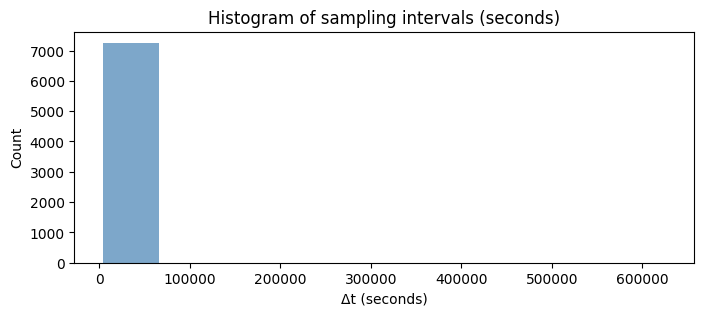

In [37]:
plt.figure(figsize=(8, 3))
plt.hist(diffs, bins=10, color="steelblue", alpha=0.7)
plt.title("Histogram of sampling intervals (seconds)")
plt.xlabel("Δt (seconds)")
plt.ylabel("Count")
plt.show()

## Dataset summary table

In [38]:
# Compute updated metrics after hourly reindexing
start_time, end_time = g.index.min(), g.index.max()
time_span_days = (end_time - start_time).total_seconds() / 86400

# Differences now perfectly 1h (except NaNs)
diffs_new = g.index.to_series().diff().dropna().dt.total_seconds()
median_gap_sec = diffs_new.median()
mode_gap_sec = diffs_new.mode().iloc[0]
regular_fraction = (diffs_new == 3600).mean()

summary = pd.DataFrame({
    "Metric": [
        "Total timestamps (rows, after reindex)",
        "Original data points (non-NaN)",
        "Added timestamps (missing hours)",
        "Time coverage (days)",
        "Start timestamp",
        "End timestamp",
        "Nominal sampling interval",
        "Regular cadence fraction",
        "Missing values (NaN, inserted gaps)",
        "Detected temperature unit",
        "Converted to Celsius",
    ],
    "Value": [
        f"{len(g):,}",
        f"{len(g) - g['is_missing'].sum():,}",
        f"{g['is_missing'].sum():,}",
        f"{time_span_days:.2f}",
        start_time.strftime("%Y-%m-%d %H:%M"),
        end_time.strftime("%Y-%m-%d %H:%M"),
        f"{median_gap_sec/3600:.2f} hours",
        f"{regular_fraction*100:.2f} %",
        f"{g['is_missing'].sum()} ({g['is_missing'].mean()*100:.2f}%)",
        "Fahrenheit (inferred from range)" if df['temp_f'].median() > 60 else "Celsius",
        "Yes" if df['temp_f'].median() > 60 else "No",
    ]
})

print(summary.to_string(index=False))

summary.to_csv("dataset_summary.csv", index=False)


                                Metric                            Value
Total timestamps (rows, after reindex)                            7,888
        Original data points (non-NaN)                            7,267
      Added timestamps (missing hours)                              621
                  Time coverage (days)                           328.62
                       Start timestamp                 2013-07-04 00:00
                         End timestamp                 2014-05-28 15:00
             Nominal sampling interval                       1.00 hours
              Regular cadence fraction                         100.00 %
   Missing values (NaN, inserted gaps)                      621 (7.87%)
             Detected temperature unit Fahrenheit (inferred from range)
                  Converted to Celsius                              Yes


## Dataset Description and Preprocessing Summary

### Interpretation

The **ambient temperature time series** consists of **7,888 hourly timestamps** covering **328.6 days**, from **2013-07-04 00:00** to **2014-05-28 15:00**.  
Out of these, **7,267 timestamps** contain recorded temperature readings, while **621 timestamps (7.87 %)** correspond to **missing hours** where the sensor produced no data.  
These gaps were identified after inspecting irregular time intervals (ranging from 2 h to several days) in the raw dataset and were explicitly **inserted as null (NaN) values** during reindexing to enforce a strict **1-hour cadence**.  
This procedure guarantees a continuous timeline suitable for time-series algorithms.  
Temperature readings ranged between **65 °F and 85 °F**, confirming the data were recorded in **Fahrenheit**; all values were therefore **converted to degrees Celsius** for subsequent analysis.

---

### 🧠 Methodological Meaning

- 🕒 **Uniform 1-hour sampling grid** → ensures equal temporal spacing for Matrix Profile computation and windowed subsequence analysis.  
- ⚙️ **621 inserted NaNs (7.87 %)** → represent genuine sensor outages or communication faults and are treated as **Type A operational anomalies**, *not* interpolated.  
- 🌡️ **Converted to Celsius** → all subsequent results and visualizations use SI units for consistency.  
- 🧩 **Perfect regular cadence (3600 s)** → Matrix Profile distances correspond to consistent hourly windows.  
- 📈 The dataset is therefore both **chronologically complete and semantically faithful**—able to capture real sensor behavior while maintaining mathematical regularity for anomaly detection experiments.



# 3. Matrix Profile computation and discord extraction

We’ll use stumpy
 — the official, optimized Python implementation of Matrix Profile.
It efficiently computes, for every subsequence of length m, the distance to its nearest neighbor, creating the Matrix Profile vector.

* Low values → repetitive or typical patterns.

* High values → unique or anomalous subsequences (discords).

## 3.1. Handle NaNs

The Matrix Profile algorithm (stumpy.stump) cannot process NaNs.
We must therefore:

* Detect where our dataset has NaNs (the 621 inserted gaps).

* Split the series into contiguous segments of valid data.

* Keep a record of where each segment starts/ends, so we can later stitch the results back together.

In [40]:
# Extract temperature as NumPy array
series = g["temp_c"].to_numpy(copy=True)

# Boolean mask: True if value is NaN (missing)
nan_mask = np.isnan(series)

segments = []
start = None

for i, is_nan in enumerate(nan_mask):
    if not is_nan and start is None:
        # We’re entering a valid numeric segment
        start = i
    elif is_nan and start is not None:
        # End of a numeric segment
        segments.append((start, i))
        start = None
if start is not None:
    segments.append((start, len(series)))  # tail segment

print(f"Detected {len(segments)} contiguous non-NaN segments.")
for s, e in segments:
    hours = e - s
    days = hours / 24
    print(f"Segment {s:5d} → {e:5d} | length = {hours:4d} h ≈ {days:5.2f} days")


Detected 11 contiguous non-NaN segments.
Segment     0 →   578 | length =  578 h ≈ 24.08 days
Segment   579 →   581 | length =    2 h ≈  0.08 days
Segment   612 →  1308 | length =  696 h ≈ 29.00 days
Segment  1355 →  1629 | length =  274 h ≈ 11.42 days
Segment  1788 →  2053 | length =  265 h ≈ 11.04 days
Segment  2148 →  2397 | length =  249 h ≈ 10.38 days
Segment  2467 →  5788 | length = 3321 h ≈ 138.38 days
Segment  5817 →  6171 | length =  354 h ≈ 14.75 days
Segment  6173 →  6317 | length =  144 h ≈  6.00 days
Segment  6331 →  6562 | length =  231 h ≈  9.62 days
Segment  6735 →  7888 | length = 1153 h ≈ 48.04 days


### Handling Missing Values (NaNs) and Anomaly Categorization

During preprocessing, the dataset was reindexed to a uniform 1-hour cadence.  
This revealed **621 missing timestamps (7.87 %)**, which were inserted as `NaN` values to preserve a continuous temporal structure.

In the context of this study, missing readings are considered **anomalies of operational nature** (e.g., sensor disconnections or data transmission failures).  
However, the **Matrix Profile (MP)** algorithm requires *continuous numeric sequences* to compute distances between subsequences.  
NaN values would disrupt this process by propagating undefined distances across the entire profile.

To address this, the time series was divided into **contiguous non-NaN segments**, and the Matrix Profile was computed **independently** for each segment.  
This approach ensures that:

- 🧩 **Computational integrity** — MP distances are computed only on valid numeric data.  
- ⚙️ **Interpretational completeness** — missing intervals remain explicitly flagged as **Type A anomalies (operational faults)**.  
- 📈 **Behavioral anomalies** (detected as high MP distances or discords) are classified as **Type B anomalies**.

The final anomaly map therefore integrates both anomaly types:

| Anomaly Type | Definition | Detected By | Example |
|---------------|-------------|-------------|----------|
| **Type A – Operational** | Missing sensor readings (NaN values) | `is_missing = 1` flag | Communication loss, sensor disconnection |
| **Type B – Behavioral** | Abnormal subsequences detected via Matrix Profile | High MP values / discords | Unusual temperature spikes, sustained drift |

By separating anomaly types in this manner, the analysis maintains both **mathematical validity** and **operational interpretability**.


## 3.2. Choosing and justifying the subsequence length m

### Selecting the Matrix Profile Subsequence Length (m)

The subsequence length `m` determines the temporal window over which similarity between time-series subsequences is evaluated.  
For the ambient-temperature dataset, each data point represents one hour; thus, `m` directly corresponds to *m hours* of behavior.  
The choice of `m` defines the type of anomalies the algorithm can capture:

| m (hours) | What it captures | What you might miss |
|------------|-----------------|---------------------|
| **3–6 h**  | Short spikes or sensor noise | Slower drifts or daily cycles |
| **24 h**   | Full daily temperature cycles | Very long trends |
| **48–72 h**| Multi-day drifts or unusual weather patterns | Small spikes get averaged out |

Because ambient temperature exhibits a strong **diurnal cycle** (a pattern that repeats every 24 hours, driven by the Earth's rotation, which causes daily fluctuations in temperature, humidity, and biological activity), the baseline behavior repeats approximately every 24 hours.  
Therefore, a subsequence length of **m = 24** (one day) was selected as the primary configuration, enabling the Matrix Profile to compare daily temperature patterns against each other.  

Additional tests with **m = 12, 48, and 72 hours** were performed to assess sensitivity to shorter and longer temporal contexts.  
This multi-scale evaluation ensures that both short-term spikes and longer-term drifts can be identified, providing a comprehensive anomaly-detection analysis.




In [ ]:
m = 24  # one day of hourly samples

m_candidates = [12, 24, 48, 72]
for m in m_candidates:
    print(f"Testing m = {m} (≈ {m/24:.1f} days window)")

# Smaller m --> detects quick fluctuations
# Larger m --> highlights prolonged anomalies

Testing m = 12 (≈ 0.5 days window)
Testing m = 24 (≈ 1.0 days window)
Testing m = 48 (≈ 2.0 days window)
Testing m = 72 (≈ 3.0 days window)


## 3.3. Matrix Profile computation (m = 24) per contiguous segment

In [ ]:
# Preconditions:
# - We already have `g` (hourly index, columns: temp_c, is_missing)
# - We already built `segments` from Step 3A-1 (list of (start, end) indices over non-NaN regions)
# - We selected m (from Step 3A-2). We'll use m=24 (one day) here.
m = 24

series = g["temp_c"].to_numpy(copy=True)

# Allocate outputs for the full timeline (same length as g)
# We’ll store profile both "start-aligned" and "center-aligned" to make plotting/labeling easier.
mp_start  = np.full(len(series), np.nan)   # profile value at each subsequence START index
mp_center = np.full(len(series), np.nan)   # profile value placed at each subsequence's CENTER timestamp
mp_nn     = np.full(len(series), -1)       # nearest-neighbor index (global) for each subsequence start

skipped = []  # segments too short for m

for (start, end) in segments:
    seg_len = end - start
    if seg_len < (m + 2):
        skipped.append((start, end))
        continue

    # Slice the valid numeric block
    seg = series[start:end]  # shape: (seg_len,)

    # Compute Matrix Profile for this block
    # mp shape: (seg_len - m + 1, 4) → columns: [profile, nn_index, ...]
    mp = stumpy.stump(seg, m)  # default ignore_trivial=True is fine here

    # Extract the profile (first column) and nearest-neighbor indices (second column)
    prof = mp[:, 0]                       # local profile values
    nn_local = mp[:, 1].astype(int)       # nearest neighbor indices (relative to start of `seg`)
    n_subseq = len(prof)                   # = seg_len - m + 1

    # Write back to global arrays:
    # 1) Start-aligned: place prof at [start : start + n_subseq]
    mp_start[start : start + n_subseq] = prof

    # 2) Center-aligned: center index = start + i + floor(m/2)
    centers = start + np.arange(n_subseq) + (m // 2)
    mp_center[centers] = prof

    # 3) Nearest-neighbor indices, remapped to global timeline
    mp_nn[start : start + n_subseq] = (start + nn_local)

# Attach results to the dataframe
g[f"mp_m{m}_start"]  = mp_start
g[f"mp_m{m}_center"] = mp_center
g[f"mp_m{m}_nn"]     = mp_nn

print(f"Computed MP (m={m}) for {len(segments) - len(skipped)} segments. Skipped {len(skipped)} short segment(s).")
print("Remaining NaNs in mp_m24_start:", np.isnan(g[f'mp_m{m}_start']).mean(), "(fraction)")
print("Remaining NaNs in mp_m24_center:", np.isnan(g[f'mp_m{m}_center']).mean(), "(fraction)")

Computed MP (m=24) for 10 segments. Skipped 1 short segment(s).
Remaining NaNs in mp_m24_start: 0.10813894523326573 (fraction)
Remaining NaNs in mp_m24_center: 0.10813894523326573 (fraction)


In [45]:
total = len(g)

# A) NaNs from gaps
gap_na = g["is_missing"].sum()

# B) NaNs from segment edges: positions where we *do* have data (not missing) but MP is NaN
edge_na = int(
    ((~g["is_missing"].astype(bool)) & g["mp_m24_start"].isna()).sum()
)

print("A) gap NaNs:", gap_na, f"({gap_na/total:.2%})")
print("B) edge NaNs:", edge_na, f"({edge_na/total:.2%})")
print("Total MP NaNs:", gap_na + edge_na, f"({(gap_na+edge_na)/total:.2%})")

A) gap NaNs: 621 (7.87%)
B) edge NaNs: 232 (2.94%)
Total MP NaNs: 853 (10.81%)
